In [3]:
!pip install transformers torch scikit-learn -q

In [4]:
import json
import torch
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn

from sklearn.model_selection import train_test_split

In [5]:
MODEL_NAME = "xlm-roberta-base"

MAX_LEN = 64
BATCH_SIZE = 8
EPOCHS = 5
LR = 2e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DATA_PATH = "/content/drive/MyDrive/dataset/dataset6.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.head())

                                  text           intent  \
0                    داخلے کب کھلیں گے  admissions_open   
1               اس سال داخلے کب ہوں گے  admissions_open   
2                 ایڈمیشن کب شروع ہوگا  admissions_open   
3  یونیورسٹی میں داخلے کی تاریخ کیا ہے  admissions_open   
4         بی ایس میں داخلے کب کھلیں گے  admissions_open   

                                ner_tags tokens  
0                           [O, O, O, O]    NaN  
1           [B-TIME, I-TIME, O, O, O, O]    NaN  
2                           [O, O, O, O]    NaN  
3                  [O, O, O, O, O, O, O]    NaN  
4  [B-PROGRAM, I-PROGRAM, O, O, O, O, O]    NaN  


In [8]:
intent_labels = sorted(df["intent"].unique())
intent2id = {v:i for i,v in enumerate(intent_labels)}
id2intent = {i:v for v,i in intent2id.items()}

df["intent_id"] = df["intent"].map(intent2id)

In [9]:
all_tags = set()
for tags in df["ner_tags"]:
    all_tags.update(tags)

ner_labels = sorted(list(all_tags))

tag2id = {t:i for i,t in enumerate(ner_labels)}
id2tag = {i:t for t,i in tag2id.items()}

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
class UrduNLUDataset(Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        text = row["text"]
        tags = row["ner_tags"]
        intent = row["intent_id"]

        encoding = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze()
        attention_mask = encoding["attention_mask"].squeeze()

        word_ids = encoding.word_ids()

        label_ids = []
        prev = None

        for w in word_ids:

            if w is None:
                label_ids.append(-100)

            elif w >= len(tags):
                label_ids.append(-100)

            elif w != prev:
                label_ids.append(tag2id[tags[w]])

            else:
                label_ids.append(tag2id[tags[w]])

            prev = w

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "intent": torch.tensor(intent),
            "ner": torch.tensor(label_ids)
        }

In [13]:
train_loader = DataLoader(UrduNLUDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(UrduNLUDataset(val_df), batch_size=BATCH_SIZE)

In [14]:
class MultiTaskNLU(nn.Module):

    def __init__(self, num_intents, num_tags):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

        hidden = 768

        self.dropout = nn.Dropout(0.3)

        self.intent_head = nn.Linear(hidden, num_intents)
        self.ner_head = nn.Linear(hidden, num_tags)

    def forward(self, input_ids, attention_mask):

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        seq = out.last_hidden_state
        pooled = seq[:,0,:]

        pooled = self.dropout(pooled)

        intent_logits = self.intent_head(pooled)
        ner_logits = self.ner_head(seq)

        return intent_logits, ner_logits

In [15]:
model = MultiTaskNLU(
    len(intent_labels),
    len(ner_labels)
).to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

intent_loss_fn = nn.CrossEntropyLoss()
ner_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

In [17]:
from tqdm import tqdm
import torch

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in loop:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        intent = batch["intent"].to(device)
        ner = batch["ner"].to(device)

        optimizer.zero_grad()

        intent_logits, ner_logits = model(input_ids, attention_mask)

        #  Intent loss
        loss1 = intent_loss_fn(intent_logits, intent)

        #  NER loss (flattened)
        loss2 = ner_loss_fn(
            ner_logits.view(-1, len(ner_labels)),
            ner.view(-1)
        )

        loss = loss1 + loss2

        #  BACKWARD
        loss.backward()

        #  GRADIENT CLIPPING (IMPORTANT FIX)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 76/76 [00:15<00:00,  5.02it/s, loss=3.43]



Epoch 1 Average Loss: 3.8374


Epoch 2: 100%|██████████| 76/76 [00:13<00:00,  5.43it/s, loss=1.94]



Epoch 2 Average Loss: 2.8036


Epoch 3: 100%|██████████| 76/76 [00:14<00:00,  5.41it/s, loss=0.999]



Epoch 3 Average Loss: 1.4405


Epoch 4: 100%|██████████| 76/76 [00:14<00:00,  5.32it/s, loss=0.352]



Epoch 4 Average Loss: 0.7720


Epoch 5: 100%|██████████| 76/76 [00:14<00:00,  5.24it/s, loss=0.463]


Epoch 5 Average Loss: 0.5187


In [18]:
ENTITY_NORMALIZATION = {

    "PROGRAM": {
        "بی ایس سی ایس": "BSCS",
        "بی ایس": "BS",
        "بی ایس آئی ٹی": "BSIT",
        "بی بی اے": "BBA",
        "بی ایس پروگرامز": "BS",
        "بی ایس کمپیوٹر سائنس": "BS Computer Science"
    },

    "TIME": {
        "اس سال": "this year",
        "اگلے سال": "next year",
        "اس مہینے": "this month",
        "آج": "today"
    },

    "CAMPUS": {
        "سرگودھا": "Sargodha Campus",
        "مین کیمپس": "Main Campus"
    }
}

def normalize_entity(label, value):

    value = value.strip()

    if label in ENTITY_NORMALIZATION:
        return ENTITY_NORMALIZATION[label].get(value, value)

    return value

In [19]:
def predict(text):

    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        intent_logits, ner_logits = model(
            encoding["input_ids"],
            encoding["attention_mask"]
        )

    intent = id2intent[torch.argmax(intent_logits, dim=1).item()]

    ner_ids = torch.argmax(ner_logits, dim=2)[0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

    #  ADD ATTENTION MASK (IMPORTANT FIX)
    attention_mask = encoding["attention_mask"][0].cpu().numpy()

    entities = {}
    current = []
    label = None

    for tok, tid, mask in zip(tokens, ner_ids, attention_mask):

        #  1. SKIP PAD TOKENS USING MASK
        if mask == 0:
            continue

        #  2. EXTRA SAFETY CHECK
        if tok in ["<pad>", "<s>", "</s>"]:
            continue

        tag = id2tag[tid]

        if tag.startswith("B-"):
            label = tag[2:]
            current = [tok]

        elif tag.startswith("I-") and label == tag[2:]:
            current.append(tok)

        else:
            if label and current:

                #  PROPER DETOKENIZATION
                raw_value = tokenizer.convert_tokens_to_string(current)

                clean_value = raw_value.replace("▁", "").strip()

                entities[label] = normalize_entity(label, clean_value)

            label = None
            current = []

    # flush last entity
    if label and current:

        raw_value = tokenizer.convert_tokens_to_string(current)

        clean_value = raw_value.replace("▁", "").strip()

        entities[label] = normalize_entity(label, clean_value)

    return {
        "intent": intent,
        "entities": entities
    }

In [20]:
predict("بی ایس سی ایس کی سالانہ فیس بتائیں")

{'intent': 'fee_structure', 'entities': {'PROGRAM': 'BSCS'}}

In [21]:
!pip install seqeval -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
from seqeval.metrics import classification_report as ner_classification_report
from seqeval.metrics import f1_score as ner_f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
def evaluate_intent(model, data_loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            intent = batch["intent"].cpu().numpy()

            intent_logits, _ = model(input_ids, attention_mask)

            preds = torch.argmax(intent_logits, dim=1).cpu().numpy()

            y_true.extend(intent)
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)

    print("\n INTENT RESULTS")
    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=intent_labels))

    return y_true, y_pred

In [24]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=intent_labels,
                yticklabels=intent_labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Intent Confusion Matrix")
    plt.show()

In [25]:
def evaluate_ner(model, data_loader):

    model.eval()

    true_tags = []
    pred_tags = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            ner = batch["ner"].numpy()

            _, ner_logits = model(input_ids, attention_mask)

            preds = torch.argmax(ner_logits, dim=2).cpu().numpy()

            for i in range(len(ner)):

                true_seq = []
                pred_seq = []

                for j in range(len(ner[i])):

                    if ner[i][j] != -100:

                        true_seq.append(id2tag[ner[i][j]])
                        pred_seq.append(id2tag[preds[i][j]])

                true_tags.append(true_seq)
                pred_tags.append(pred_seq)

    print("\n NER RESULTS")
    print(ner_classification_report(true_tags, pred_tags))

    print("\nNER F1 Score:", ner_f1_score(true_tags, pred_tags))

    return true_tags, pred_tags


 INTENT RESULTS
Accuracy: 0.9869281045751634

Classification Report:

                    precision    recall  f1-score   support

admission_deadline       0.95      1.00      0.98        20
   admissions_open       1.00      0.94      0.97        16
     apply_process       1.00      1.00      1.00        14
documents_required       1.00      1.00      1.00        15
       eligibility       1.00      0.94      0.97        16
        entry_test       1.00      1.00      1.00        19
     fee_structure       1.00      1.00      1.00        12
    merit_criteria       0.93      1.00      0.96        13
      office_hours       1.00      1.00      1.00        12
  programs_offered       1.00      1.00      1.00        16

          accuracy                           0.99       153
         macro avg       0.99      0.99      0.99       153
      weighted avg       0.99      0.99      0.99       153



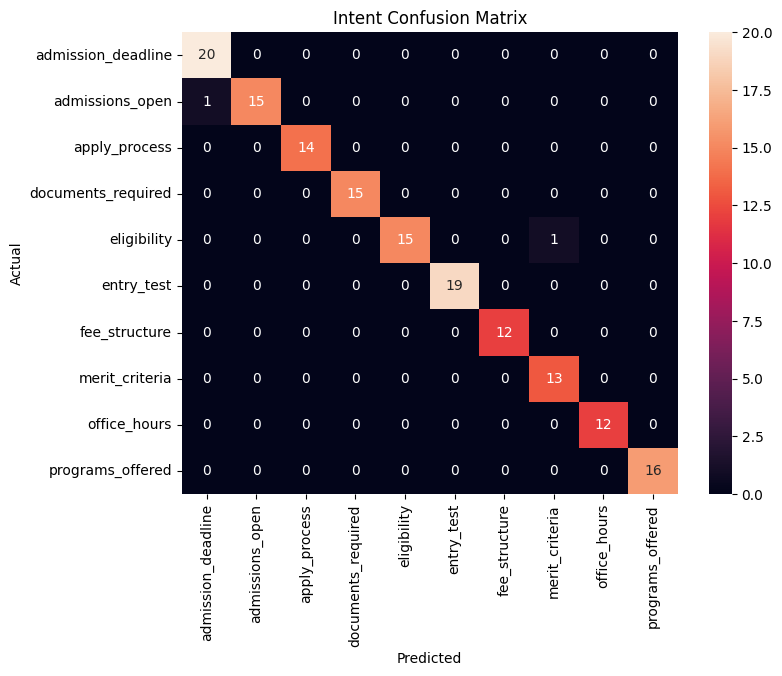


 NER RESULTS
               precision    recall  f1-score   support

     ATE_TIME       0.00      0.00      0.00        10
DOCUMENT_TYPE       0.39      0.90      0.55        20
      EE_TYPE       0.90      0.95      0.92        19
    ERIT_TYPE       0.88      1.00      0.93        14
     EST_TYPE       0.86      0.95      0.90        19
    FORM_TYPE       0.60      0.27      0.37        11
    Form_Type       0.35      0.50      0.41        14
  INSTITUTION       0.00      0.00      0.00         2
   MERIT_TYPE       1.00      1.00      1.00         7
       METRIC       0.00      0.00      0.00         6
 OCUMENT_TYPE       0.00      0.00      0.00         7
  OFFICE_TYPE       0.00      0.00      0.00         5
      PROGRAM       0.53      0.85      0.65        39
      Program       0.00      0.00      0.00         9
      SESSION       0.00      0.00      0.00         2
    TEST_TYPE       0.85      1.00      0.92        11
         TIME       0.00      0.00      0.00      

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: MERIT_TYPE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: TEST_TYPE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DATE_TIME seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: FEE_TYPE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: DOCUMENT_TYPE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/met

In [26]:
# INTENT EVALUATION
y_true, y_pred = evaluate_intent(model, val_loader)

# CONFUSION MATRIX
plot_confusion_matrix(y_true, y_pred)

# NER EVALUATION
true_tags, pred_tags = evaluate_ner(model, val_loader)

In [27]:
import os
import json
import torch

SAVE_DIR = "/content/urdu_nlu_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), f"{SAVE_DIR}/model.pt")

# Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# Save mappings
with open(f"{SAVE_DIR}/intent2id.json", "w", encoding="utf-8") as f:
    json.dump(intent2id, f, ensure_ascii=False, indent=2)

with open(f"{SAVE_DIR}/tag2id.json", "w", encoding="utf-8") as f:
    json.dump(tag2id, f, ensure_ascii=False, indent=2)

with open(f"{SAVE_DIR}/entity_normalization.json", "w", encoding="utf-8") as f:
    json.dump(ENTITY_NORMALIZATION, f, ensure_ascii=False, indent=2)

print("Model saved successfully.")

Model saved successfully.


In [30]:
model.encoder.config.save_pretrained("/content/urdu_nlu_model")

In [31]:
tokenizer.save_pretrained("/content/urdu_nlu_model")

('/content/urdu_nlu_model/tokenizer_config.json',
 '/content/urdu_nlu_model/tokenizer.json')

In [33]:
!ls /content/urdu_nlu_model

config.json		   model.pt		  tokenizer.json
entity_normalization.json  tag2id.json
intent2id.json		   tokenizer_config.json


In [34]:
from transformers import AutoTokenizer

tokenizer_test = AutoTokenizer.from_pretrained("/content/urdu_nlu_model")

print("Tokenizer loaded successfully")

Tokenizer loaded successfully


In [35]:
!zip -r urdu_nlu_model.zip /content/urdu_nlu_model

updating: content/urdu_nlu_model/ (stored 0%)
updating: content/urdu_nlu_model/model.pt (deflated 30%)
updating: content/urdu_nlu_model/intent2id.json (deflated 35%)
updating: content/urdu_nlu_model/tokenizer.json (deflated 77%)
updating: content/urdu_nlu_model/tokenizer_config.json (deflated 47%)
updating: content/urdu_nlu_model/entity_normalization.json (deflated 45%)
updating: content/urdu_nlu_model/tag2id.json (deflated 61%)
updating: content/urdu_nlu_model/config.json (deflated 50%)
